# 07a. 디스크 단위 임계값 튜닝 및 그리드 서치 (Disk-Level Threshold Tuning)

이 노트북은 행(Row) 단위 임계값 평가 대신, 실제 운영 관점에서 가장 중요한 **디스크(Base Serial) 단위**로 그리드 서치를 수행합니다.
단순히 특정 임계값을 넘는 순간 알람을 주는 탐지 정책(Anytime Alarm)뿐만 아니라, **"고장 알람이 최소 $n$회 이상 발생했을 때 실제 고장으로 판단하는 로직"**을 추가하여 통계를 산출합니다.

### 평가 지표 체계 (우선순위별)

| 우선순위 | 지표 | 의미 | 계산 방식 |
| :---: | :--- | :--- | :--- |
| **S** | **Disk Recall** | 실제 고장 디스크 중 탐지된 비율 | $TP_{disk} / N_{failed\_disks}$ |
| **S** | **Disk FAR** | 정상 디스크 중 오탐(False Alarm)이 발생한 비율 | $FP_{disk} / N_{normal\_disks}$ |
| **S** | **Lead Time** | 첫 탐지 시점부터 실제 고장일까지의 평균 일수 | $Mean(Last\_Date - Trigger\_Date)$ |
| **A** | **Precision** | 경보가 발생한 디스크 중 실제 고장 디스크의 비율 | $TP_{disk} / (TP_{disk} + FP_{disk})$ |
| **A** | **Alarm Persistence** | 첫 탐지 이후 지속적으로 경고를 발령했는지의 비율 | $Mean(Alarm\_Days\_After\_Trigger / Total\_Days\_After\_Trigger)$ |
| **A** | **Failure Window Hit Rate** | 고장 직전 10일 구간 내 탐지 성공 여부 | 고장 직전 10일 중 최소 1회 이상 탐지한 디스크 비율 |
| **B** | **Alarm Density** | 고장에 가까워질수록 경고 빈도가 증가하는지 여부 | (고장 직전 10일의 알람 빈도) / (이전 구간의 알람 빈도) 비율 |
| **B** | **Consecutive Alarm Length** | 최장 연속 알람 발생 기간 | 각 디스크별 최장 연속 알람 발생일수의 평균 |
| **B** | **Alert Burden** | 시스템 전체의 경보 운영 부담량 | 디스크당 평균 알람 발생 횟수 |
| **C** | **Calibration** | 예측 확률 스코어의 물리적 해석 가능성 | 디스크별 최대 예측 확률과 실제 레이블 간의 Brier Score (MSE) |

---

## 1. 환경 설정 및 라이브러리 로드

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))  # 프로젝트 루트 경로 추가

# 코드 변경 자동 반영 (autoreload)
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

import config.threshold_config as cfg
from src.eval_core import (
    load_saved_ensemble,
    prepare_disk_level_data,
    run_disk_level_grid_search,
    evaluate_detailed_disk_point,
    plot_disk_far_recall_curves,
    plot_detailed_disk_analysis
)

# 한글 폰트 설정
import matplotlib.font_manager as fm
def set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("✅ 환경 설정 및 라이브러리 로드 완료")

✅ 환경 설정 및 라이브러리 로드 완료


## 2. 최종 모델 및 val_calib 데이터 로드

In [2]:
print("🔄 최종 모델 로드 중...")
artifacts = load_saved_ensemble(cfg, require_threshold=False)
feature_cols = artifacts["feature_cols"]
ensemble = artifacts["ensemble"]
print(f"✅ 모델 로드 완료: {len(feature_cols)}개 피처")

print("🔄 val_calib 데이터 로드 중...")
val_calib_path = Path(cfg.VAL_CALIB_PATH)
df_val = pd.read_parquet(val_calib_path)
print(f"✅ 데이터 로드 완료: {len(df_val):,} 행")

🔄 최종 모델 로드 중...

[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (591 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (27 features)
  model: subset_00.pkl (9,539,044 bytes)
  model: subset_01.pkl (9,555,780 bytes)
  model: subset_02.pkl (9,557,204 bytes)
  model: subset_03.pkl (9,556,372 bytes)
  model: subset_04.pkl (9,563,556 bytes)
  model: subset_05.pkl (9,557,892 bytes)
  model: subset_06.pkl (9,558,804 bytes)
  model: subset_07.pkl (9,548,164 bytes)
  model: subset_08.pkl (9,552,068 bytes)
  model: subset_09.pkl (9,530,612 bytes)
  joblib 로드 1/10: subset_00.pkl
      → 0.2s
  joblib 로드 2/10: subset_01.pkl
      → 0.0s
  joblib 로드 3/10

## 3. 앙상블 예측 수행 및 캐싱 (Validation Probabilities)

In [3]:
cache_path = os.path.join(cfg.MODEL_SAVE_DIR, "val_calib_probs.npy")

if os.path.exists(cache_path):
    print("♻️ 캐시된 예측 확률 파일 로드 중...")
    y_prob = np.load(cache_path)
    print(f"✅ 로드 완료: {len(y_prob):,}행")
else:
    t0 = time.perf_counter()
    print("🔄 앙상블 예측 수행 중...")
    y_prob = ensemble.predict_proba(df_val, feature_cols, verbose=True)
    np.save(cache_path, y_prob)
    print(f"✅ 예측 완료 및 캐시 저장 완료! 소요 시간: {time.perf_counter() - t0:.1f}초")

df_val['y_prob'] = y_prob

♻️ 캐시된 예측 확률 파일 로드 중...
✅ 로드 완료: 7,832,520행


## 4. 디스크 단위(Base Serial) 시계열 데이터 구성

In [4]:
print("🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...")
t0 = time.perf_counter()
disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
    df_val, y_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
)
print(f"✅ 정렬 및 데이터 변환 완료: 총 {len(disks_data):,}개 디스크 (소요: {time.perf_counter() - t0:.2f}초)")
print(f"  - 고장 디스크 수 (Failed Disks) : {n_failed_disks:,}")
print(f"  - 정상 디스크 수 (Normal Disks) : {n_normal_disks:,}")

🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...
✅ 정렬 및 데이터 변환 완료: 총 3,691개 디스크 (소요: 4.23초)
  - 고장 디스크 수 (Failed Disks) : 565
  - 정상 디스크 수 (Normal Disks) : 3,126


## 5. 벡터화된 초고속 그리드 서치 수행 (FAR & Recall)

In [5]:
thresholds = np.linspace(0.001, 0.999, 1000)
min_alarms_list = [1, 2, 3, 4, 5]

print(f"🔄 초고속 벡터화 그리드 서치 수행 중: {len(thresholds) * len(min_alarms_list)}개 조합 (window_size={cfg.ALARM_WINDOW})...")
t_grid = time.perf_counter()
df_grid = run_disk_level_grid_search(disks_data, thresholds, min_alarms_list, n_failed_disks, n_normal_disks, log_dir=cfg.MODEL_SAVE_DIR, window_size=cfg.ALARM_WINDOW)

# 그리드 서치 결과 전체 CSV 파일로 저장
grid_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, 'disk_level_grid_search_results.csv')
df_grid.to_csv(grid_csv_path, index=False, encoding='utf-8-sig')
print(f"✅ 디스크 단위 5,000개 조합 그리드 서치 결과 CSV 저장 완료: {grid_csv_path}")
print(f"✅ 벡터화 그리드 서치 완료: 총 {len(df_grid)}개 조합 탐색 완료 (소요: {time.perf_counter() - t_grid:.4f}초)")

🔄 초고속 벡터화 그리드 서치 수행 중: 5000개 조합 (window_size=14)...
  ... 500/5,000 (10.0%) - 0.0s
  ... 1,000/5,000 (20.0%) - 0.0s
  ... 1,500/5,000 (30.0%) - 0.0s
  ... 2,000/5,000 (40.0%) - 0.0s
  ... 2,500/5,000 (50.0%) - 0.1s
  ... 3,000/5,000 (60.0%) - 0.1s
  ... 3,500/5,000 (70.0%) - 0.1s
  ... 4,000/5,000 (80.0%) - 0.1s
  ... 4,500/5,000 (90.0%) - 0.1s
  ... 5,000/5,000 (100.0%) - 0.1s
✅ 디스크 단위 5,000개 조합 그리드 서치 결과 CSV 저장 완료: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\disk_level_grid_search_results.csv
✅ 벡터화 그리드 서치 완료: 총 5000개 조합 탐색 완료 (소요: 5.8664초)


## 6. 오탐율(Disk FAR) 상한별 최적 운영점 도출 및 세부 지표 산출

In [6]:
target_far_caps = [0.001, 0.005, 0.010, 0.020, 0.030, 0.050]
detailed_best_points = []

print("=" * 115)
print(f"{'FPR Cap':^10} | {'min_alarms':^10} | {'threshold':^10} | {'Disk Recall':^12} | {'Disk FAR':^10} | {'Lead Time':^10} | {'Precision':^10} | {'Persist.':^10}")
print("=" * 115)

for cap in target_far_caps:
    valid_rows = df_grid[df_grid['far'] <= cap]
    if len(valid_rows) == 0:
        continue
    best_row = valid_rows.loc[valid_rows['recall'].idxmax()]
    
    det = evaluate_detailed_disk_point(
        disks_data, best_row['threshold'], int(best_row['min_alarms']),
        n_failed_disks, n_normal_disks, far_cap=cap, window_size=cfg.ALARM_WINDOW
    )
    detailed_best_points.append(det)
    
    print(f"{cap*100:8.1f}% | {int(det['min_alarms']):9d} | {det['threshold']:9.4f} | "
          f"{det['recall']*100:10.2f}% | {det['far']*100:8.2f}% | {det['lead_time']:8.1f}일 | "
          f"{det['precision']:9.4f} | {det['persistence']:8.4f}")
print("=" * 115)

df_detailed_best = pd.DataFrame(detailed_best_points)
df_detailed_best.to_csv(os.path.join(cfg.MODEL_SAVE_DIR, "disk_level_best_operating_points_detailed.csv"), index=False, encoding='utf-8-sig')

 FPR Cap   | min_alarms | threshold  | Disk Recall  |  Disk FAR  | Lead Time  | Precision  |  Persist. 
     0.1% |         1 |    0.9820 |      16.64% |     0.10% |     32.5일 |    0.9691 |   0.5694
     0.5% |         1 |    0.9720 |      27.61% |     0.48% |     49.6일 |    0.9123 |   0.4818
     1.0% |         2 |    0.9261 |      38.76% |     0.93% |    104.1일 |    0.8831 |   0.5914
     2.0% |         1 |    0.9401 |      47.79% |     1.95% |    122.4일 |    0.8157 |   0.4857
     3.0% |         2 |    0.8631 |      55.58% |     2.94% |    140.9일 |    0.7734 |   0.6122
     5.0% |         1 |    0.8511 |      64.96% |     4.99% |    167.8일 |    0.7017 |   0.5569


## 7. 오탐율(Disk FAR) - 탐지율(Disk Recall) 곡선 시각화

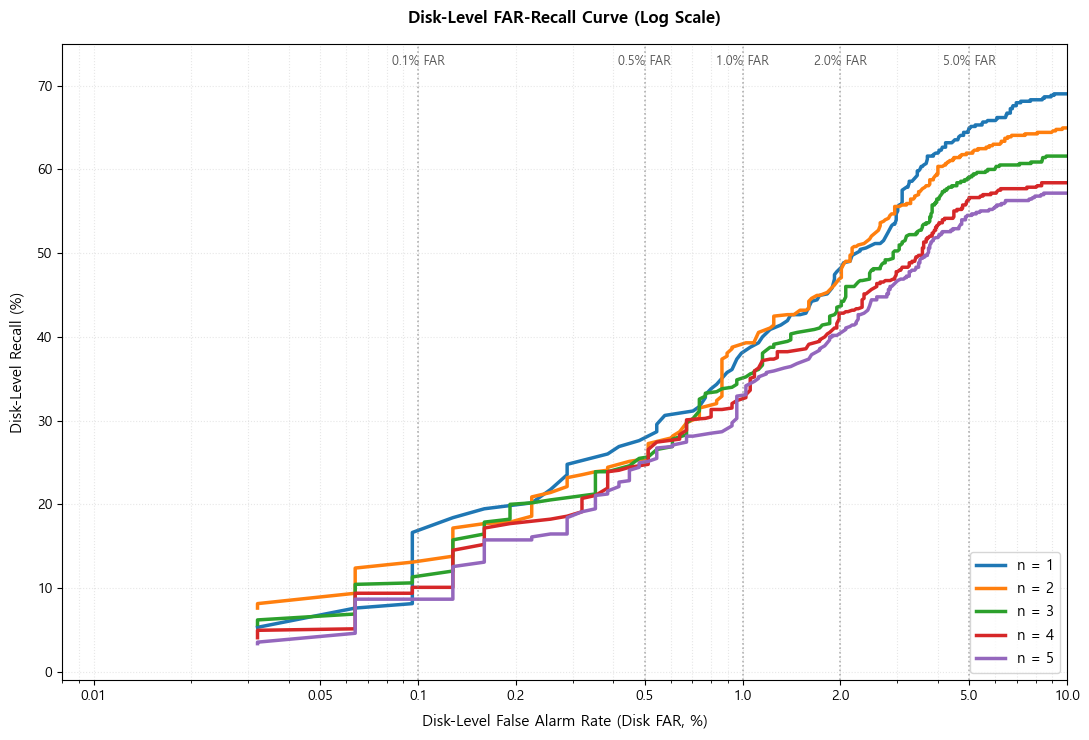

In [7]:
# FAR 1.0% 이하에서 가장 높은 Recall을 주는 최적 운영점 선택
opt_row = df_grid[df_grid['far'] <= 0.01].sort_values('recall', ascending=False).iloc[0]
plot_disk_far_recall_curves(df_grid, min_alarms_list, opt_row)

## 8. 최적 운영점 세부 성능 지표 및 통계 분포 시각화

🎯 적용할 최적 운영점: 임계값 T = 0.9261, 최소 알람 수 n = 2 (window_size=14)
[OK] 최적 운영점 기준 개별 디스크 세부 통계 (calib) CSV 저장 완료: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\best_disk_lead_time_distribution_calib.csv
  [최적 운영점 최종 스냅샷] T = 0.9261, n = 2 (Rolling W=14)
  Disk Recall (탐지율)          : 38.76%
  Disk FAR (오탐율)             : 0.93%
  Precision (경고 신뢰도)        : 0.8831
  Brier Score (Calibration)     : 0.14049
  Average Lead Time (리드타임)   : 104.05일
  Alarm Persistence (지속도)    : 59.14%
  Failure Window Hit Rate       : 29.91%
  Alarm Density Ratio (증가비)   : 21.18배
  Average Consecutive Length    : 0.79일
  Average Alert Burden          : 1.25일


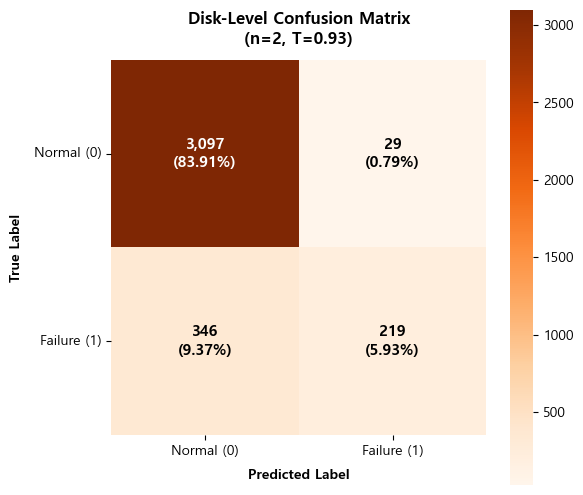

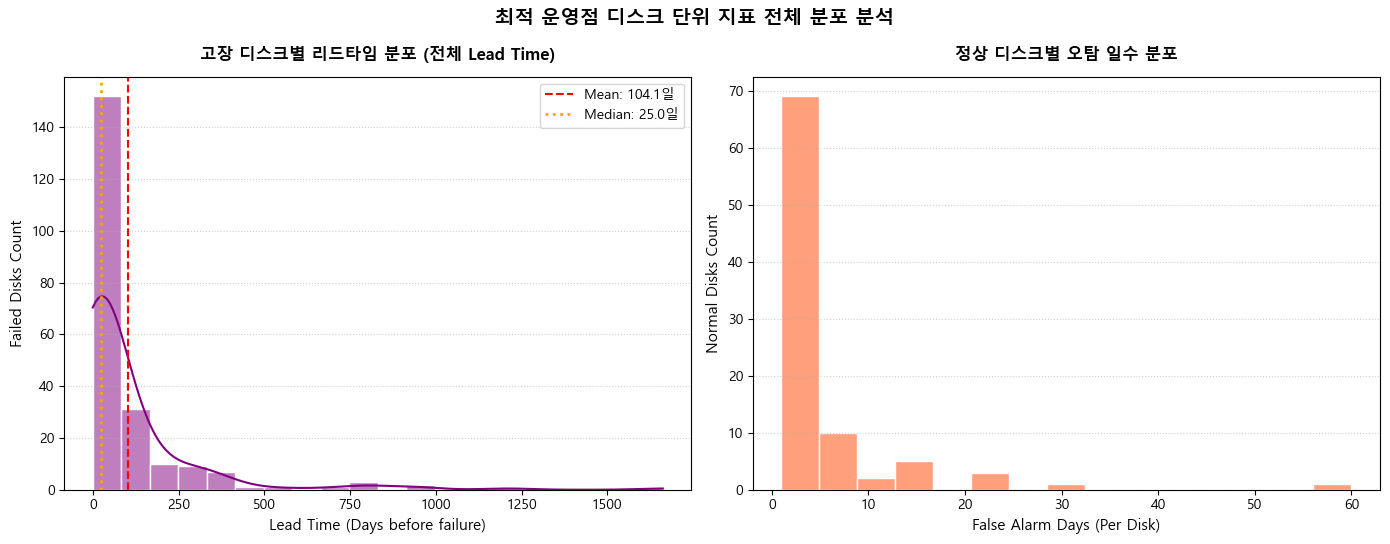

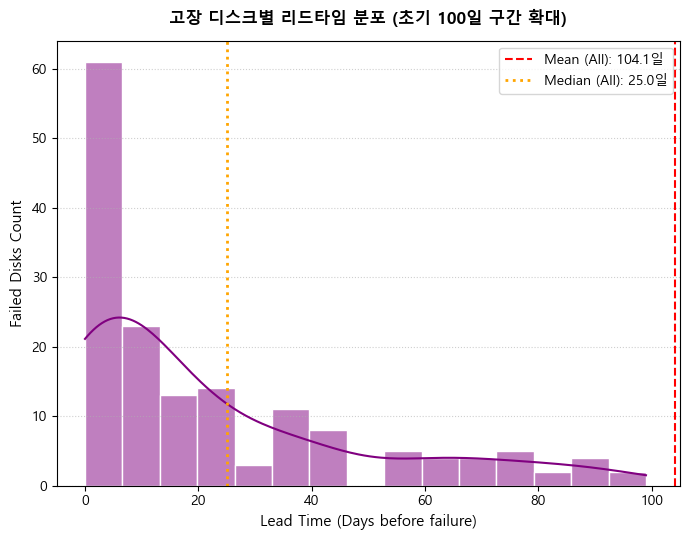

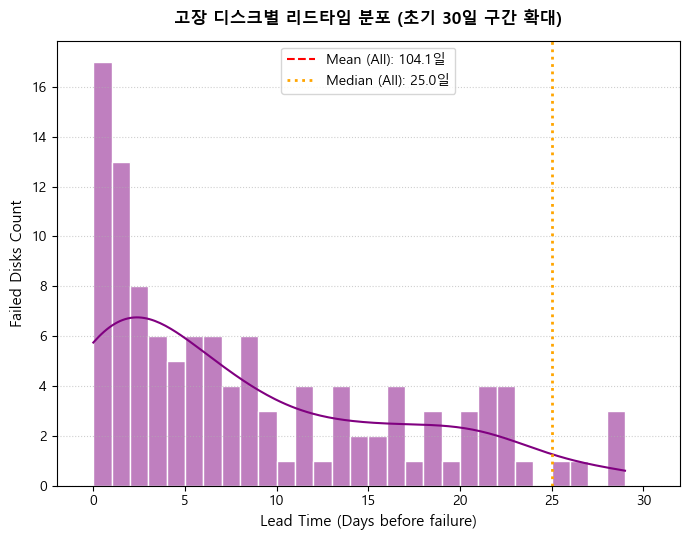

In [8]:
BEST_T = float(opt_row['threshold'])
BEST_N = int(opt_row['min_alarms'])

print(f"🎯 적용할 최적 운영점: 임계값 T = {BEST_T:.4f}, 최소 알람 수 n = {BEST_N} (window_size={cfg.ALARM_WINDOW})")
stats = evaluate_detailed_disk_point(disks_data, BEST_T, BEST_N, n_failed_disks, n_normal_disks, window_size=cfg.ALARM_WINDOW)

# 세부 통계 산출을 위해 리스트에서 개별 디스크별 데이터 추출
best_disk_records = []
for disk in disks_data:
    probs = disk['probs']
    y_pred = (probs >= BEST_T).astype(int)
    total_alarms = y_pred.sum()
    
    if cfg.ALARM_WINDOW is not None and cfg.ALARM_WINDOW > 0:
        rolling_alarms = pd.Series(y_pred).rolling(window=cfg.ALARM_WINDOW, min_periods=1).sum().values
        is_alarmed = int((rolling_alarms >= BEST_N).any())
    else:
        is_alarmed = int(total_alarms >= BEST_N)
    
    max_consec = 0; curr_consec = 0
    for val in y_pred:
        if val == 1:
            curr_consec += 1
            if curr_consec > max_consec: max_consec = curr_consec
        else: curr_consec = 0
            
    lead_time = np.nan
    persistence = np.nan
    
    if disk['is_failed'] == 1 and is_alarmed == 1:
        if cfg.ALARM_WINDOW is not None and cfg.ALARM_WINDOW > 0:
            rolling_alarms = pd.Series(y_pred).rolling(window=cfg.ALARM_WINDOW, min_periods=1).sum().values
            trigger_idx = np.where(rolling_alarms >= BEST_N)[0][0]
        else:
            trigger_idx = np.where(y_pred == 1)[0][BEST_N - 1]
            
        trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
        last_date = pd.to_datetime(disk['dates'][-1])
        lead_time = (last_date - trigger_date).days
        
        alarms_after = y_pred[trigger_idx:].sum()
        days_after = len(y_pred[trigger_idx:])
        persistence = alarms_after / days_after if days_after > 0 else 0.0
        
    best_disk_records.append({
        'base_serial': disk['base_serial'],
        'is_failed': disk['is_failed'],
        'is_alarmed': is_alarmed,
        'total_alarms': total_alarms,
        'max_consec': max_consec,
        'lead_time': lead_time,
        'persistence': persistence
    })

df_best_disk = pd.DataFrame(best_disk_records)

# [요구사항] 최적 운영점 기준 개별 디스크별 예측/리드타임 세부 통계를 calib 데이터셋용 파일로 저장
best_disk_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, 'best_disk_lead_time_distribution_calib.csv')
df_best_disk.to_csv(best_disk_csv_path, index=False, encoding='utf-8-sig')
print(f'[OK] 최적 운영점 기준 개별 디스크 세부 통계 (calib) CSV 저장 완료: {best_disk_csv_path}')

# 혼동행렬 구성 요소 집계
tp = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 1)).sum())
fn = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 0)).sum())
fp = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 1)).sum())
tn = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 0)).sum())

print("=" * 65)
print(f"  [최적 운영점 최종 스냅샷] T = {BEST_T:.4f}, n = {BEST_N} (Rolling W={cfg.ALARM_WINDOW})")
print("=" * 65)
print(f"  Disk Recall (탐지율)          : {stats['recall']*100:.2f}%")
print(f"  Disk FAR (오탐율)             : {stats['far']*100:.2f}%")
print(f"  Precision (경고 신뢰도)        : {stats['precision']:.4f}")
print(f"  Brier Score (Calibration)     : {stats['calibration']:.5f}")
print(f"  Average Lead Time (리드타임)   : {stats['lead_time']:.2f}일")
print(f"  Alarm Persistence (지속도)    : {stats['persistence']*100:.2f}%")
print(f"  Failure Window Hit Rate       : {stats['fw_hit_rate']*100:.2f}%")
print(f"  Alarm Density Ratio (증가비)   : {stats['density_ratio']:.2f}배")
print(f"  Average Consecutive Length    : {stats['consec_len']:.2f}일")
print(f"  Average Alert Burden          : {stats['alert_burden']:.2f}일")
print("=" * 65)

plot_detailed_disk_analysis(stats, df_best_disk, tp, fn, fp, tn)